# # I will be analyzing the West Colorado region, along with the Northeast Maryland region.
# # My territory managers are Jim Heck (Colorado) and Shruti Reddy (Maryland).

In [102]:
import pandas as pd

In [103]:
import matplotlib.pyplot as plt

In [113]:
pd.read_csv('customer_list.csv')

,Customer_Id,Date,Time,Name,Email,Phone,SMS Opt-Out
0,1,3/15/2023,8:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,5/22/2023,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,7/9/2023,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,9/1/2023,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,11/18/2023,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N
...,...,...,...,...,...,...,...
516,517,2/15/2024,11:30:30,Perry the Platypus,agentp@danvillekids.com,555-555-3206,N
517,518,5/1/2024,15:55:45,Baljeet,baljeet@danvillekids.com,555-555-3207,N
518,519,3/5/2023,9:20:00,Buford,buford@danvillekids.com,555-555-3208,N
519,520,5/18/2023,13:45:15,Vanessa D.,vanessa@danvillekids.com,555-555-3209,N


In [105]:
pd.read_csv('Products.csv')

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab
...,...,...,...,...
664,105912-T,Networking Fundamentals,100,100-tec
665,105913-T,Introduction to Databases,100,100-tec
666,105914-IT,SanDisk Extreme Portable SSD (1TB),120,120-ext
667,105915-M,LTCA Year Up Spiral Notebook (Black),130,130-off


In [106]:
pd.read_csv('ProductCategories.csv')

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories
5,120,Technology & Accessories,120-cha,Chargers and Power Adapters
6,120,Technology & Accessories,120-lap,Laptops
7,130,Apparel and Merchandise,130-off,Office and Study Supplies
8,100,Textbooks,100-bus,Business & Economics
9,130,Apparel and Merchandise,130-clo,"Clothing (T-Shirts, Hoodies, and Jackets)"


In [107]:
pd.read_csv('StoreDetail.csv')

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers
...,...,...,...,...,...,...
106,Dallas,Texas,907,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
107,Denton,Texas,908,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
108,Desoto,Texas,909,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
109,Fort Worth,Texas,910,"Jeff ""Howdy"" Richards",South,Andy Gisselquist


In [108]:
pd.read_csv('StoreSales.csv')

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36
...,...,...,...,...,...
335124,12/31/2025,909,NaN,105353-A,20.36
335125,12/31/2025,909,332.0,105364-S,17.70
335126,12/31/2025,910,NaN,105672-B,26.52
335127,12/31/2025,910,NaN,105653-M,11.00


# Core Marketing Analysis

The territory managers for the assigned territories are;
Jim Heck - West Colorado
Shruti Reddy - Northeast Maryland 

In [109]:
store_id = pd.read_csv('StoreDetail.csv', usecols=[0, 2])
print(store_id)

    Store Location  Store ID
0           Aurora       701
1         Berthoud       702
2          Boulder       703
3      Castle Rock       704
4           Denver       705
..             ...       ...
106         Dallas       907
107         Denton       908
108         Desoto       909
109     Fort Worth       910
110     Georgetown       911

[111 rows x 2 columns]


In [135]:
df = pd.read_csv('StoreSales.csv')
print(df.head())
print(df.columns)

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
monthlytotal = df.groupby(df['Transaction Date'].dt.to_period('M'))['Sale Amount'].sum()
monthlytotal = monthly_revenue.reset_index()
monthlytotal['Transaction Date'] = monthlytotal['Transaction Date'].astype(str)

print(monthlytotal)

  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount
0         1/1/2022       702        NaN  105349-M         8.00
1         1/1/2022       704        NaN  105350-T       144.00
2         1/1/2022       705        NaN  105351-M        44.00
3         1/1/2022       705        NaN  105352-M        47.61
4         1/1/2022       705        NaN  105353-A        20.36
Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount'], dtype='str')
    index Transaction Date  Sale Amount
0       0          2022-01    610945.43
1       1          2022-02    622272.35
2       2          2022-03    660349.58
3       3          2022-04    650453.95
4       4          2022-05    681687.71
5       5          2022-06    658483.42
6       6          2022-07    689840.65
7       7          2022-08    671138.48
8       8          2022-09    596975.23
9       9          2022-10    671127.85
10     10          2022-11    618880.62
11     11          2022-12    682707.45
12     12

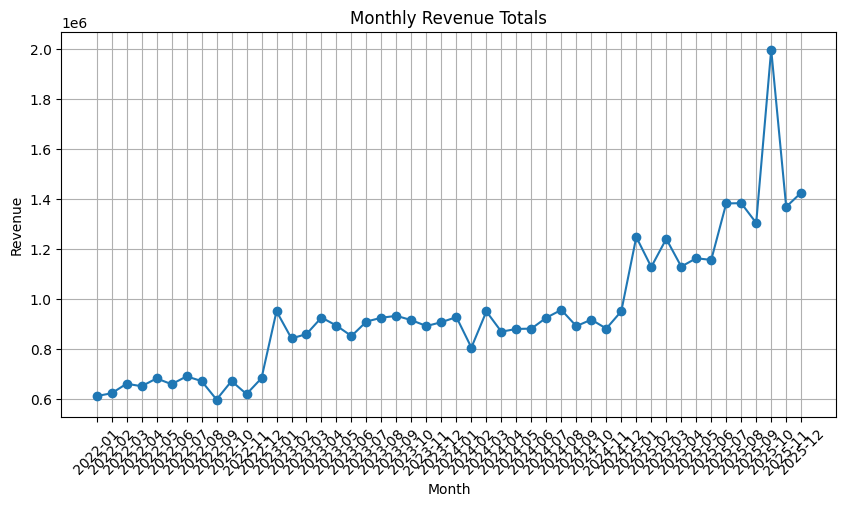

In [180]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue['Transaction Date'],
    monthly_revenue['Sale Amount'],
    marker='o'
)

plt.title('Monthly Revenue Totals')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

The highest performing store in Northeast Maryland is Store 737.
The highest performing store in West Colorado is Store 711.

In [141]:
customerid = pd.read_csv('customer_list.csv', usecols=[0])
print(customerid)

rewardid = pd.read_csv('StoreSales.csv', usecols=[2])
print(rewardid)

     Customer_Id
0              1
1              2
2              3
3              4
4              5
..           ...
516          517
517          518
518          519
519          520
520          521

[521 rows x 1 columns]
        RewardsID
0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
...           ...
335124        NaN
335125      332.0
335126        NaN
335127        NaN
335128        NaN

[335129 rows x 1 columns]


The top customers in the West Colorado region shopped at Store 702 with a reward id of 521 and a sale amount of 8.
The top customers in the Northeast Maryland region shopped at Store 731 with a reward id of 521 and a sale amount of 23.44.

In [142]:
saleamount = pd.read_csv('StoreSales.csv', usecols=[4])
print(saleamount)
category = pd.read_csv('ProductCategories.csv', usecols=[1])
print(category)

        Sale Amount
0              8.00
1            144.00
2             44.00
3             47.61
4             20.36
...             ...
335124        20.36
335125        17.70
335126        26.52
335127        11.00
335128        77.81

[335129 rows x 1 columns]
                    Category
0   Technology & Accessories
1   Technology & Accessories
2   Technology & Accessories
3   Technology & Accessories
4   Technology & Accessories
5   Technology & Accessories
6   Technology & Accessories
7    Apparel and Merchandise
8                  Textbooks
9    Apparel and Merchandise
10   Apparel and Merchandise
11              Art Supplies
12           Books (General)
13   Stationery and Supplies
14                 Textbooks
15              Art Supplies
16                 Textbooks
17   Stationery and Supplies
18                 Textbooks
19                 Textbooks
20   Stationery and Supplies
21                 Textbooks
22   Stationery and Supplies
23                 Textbooks
24   App

In [168]:
df = pd.read_csv('StoreSales.csv')
print(df.head())
print(df.columns)

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
monthlyrevenue = df.groupby(df['Transaction Date'].dt.to_period('M'))['Sale Amount'].count()
monthlyrevenue = monthly_revenue.reset_index()
monthlyrevenue['Transaction Date'] = monthlyrevenue['Transaction Date'].astype(str)

print(monthlytotal)

  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount
0         1/1/2022       702      521.0  105349-M         8.00
1         1/1/2022       704      521.0  105350-T       144.00
2         1/1/2022       705      521.0  105351-M        44.00
3         1/1/2022       705      521.0  105352-M        47.61
4         1/1/2022       705      521.0  105353-A        20.36
Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount'], dtype='str')
    index Transaction Date  Sale Amount
0       0          2022-01    610945.43
1       1          2022-02    622272.35
2       2          2022-03    660349.58
3       3          2022-04    650453.95
4       4          2022-05    681687.71
5       5          2022-06    658483.42
6       6          2022-07    689840.65
7       7          2022-08    671138.48
8       8          2022-09    596975.23
9       9          2022-10    671127.85
10     10          2022-11    618880.62
11     11          2022-12    682707.45
12     12

  Transaction Date                  Category  Transaction Count
0          2022-01   Apparel and Merchandise                  8
1          2022-01              Art Supplies                 11
2          2022-01           Books (General)                  4
3          2022-01   Stationery and Supplies                 11
4          2022-01  Technology & Accessories                  7
5          2022-01                 Textbooks                 11
  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount
0         1/1/2022       702      521.0  105349-M         8.00
1         1/1/2022       704      521.0  105350-T       144.00
2         1/1/2022       705      521.0  105351-M        44.00
3         1/1/2022       705      521.0  105352-M        47.61
4         1/1/2022       705      521.0  105353-A        20.36
Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount'], dtype='str')
   CategoryID                  Category SubcategoryID           Subcategory
0    

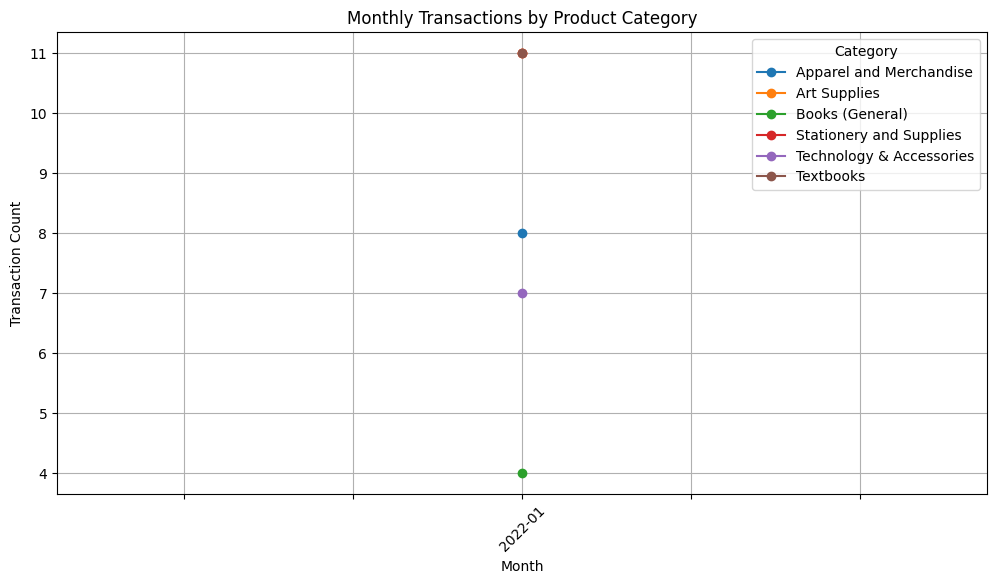

In [166]:
df = pd.read_csv('StoreSales.csv')
dff = pd.read_csv('ProductCategories.csv')

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
monthly_category_transactions = df.groupby([
    df['Transaction Date'].dt.to_period('M'),
    dff['Category'],
])['Sale Amount'].count()

monthly_category_transactions = (
    monthly_category_transactions.reset_index()
)


monthly_category_transactions.rename(
    columns={'Sale Amount': 'Transaction Count'},
    inplace=True
)


monthly_category_transactions['Transaction Date'] = (
    monthly_category_transactions['Transaction Date'].astype(str)
)


print(monthly_category_transactions)

df = pd.read_csv('StoreSales.csv')
print(df.head())
print(df.columns)

dff = pd.read_csv('ProductCategories.csv')
print(dff.head())
print(dff.columns)

pivot_table = monthly_category_transactions.pivot(
    index='Transaction Date',
    columns='Category',
    values='Transaction Count'
)

pivot_table.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Monthly Transactions by Product Category')
plt.xlabel('Month')
plt.ylabel('Transaction Count')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

  Transaction Date                  Category  Revenue Total
0          2022-01   Apparel and Merchandise         400.32
1          2022-01              Art Supplies         698.25
2          2022-01           Books (General)         338.42
3          2022-01   Stationery and Supplies        2688.58
4          2022-01  Technology & Accessories         662.14
5          2022-01                 Textbooks         862.95
  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount
0         1/1/2022       702      521.0  105349-M         8.00
1         1/1/2022       704      521.0  105350-T       144.00
2         1/1/2022       705      521.0  105351-M        44.00
3         1/1/2022       705      521.0  105352-M        47.61
4         1/1/2022       705      521.0  105353-A        20.36
Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount'], dtype='str')
   CategoryID                  Category SubcategoryID           Subcategory
0         120  Technology & Acces

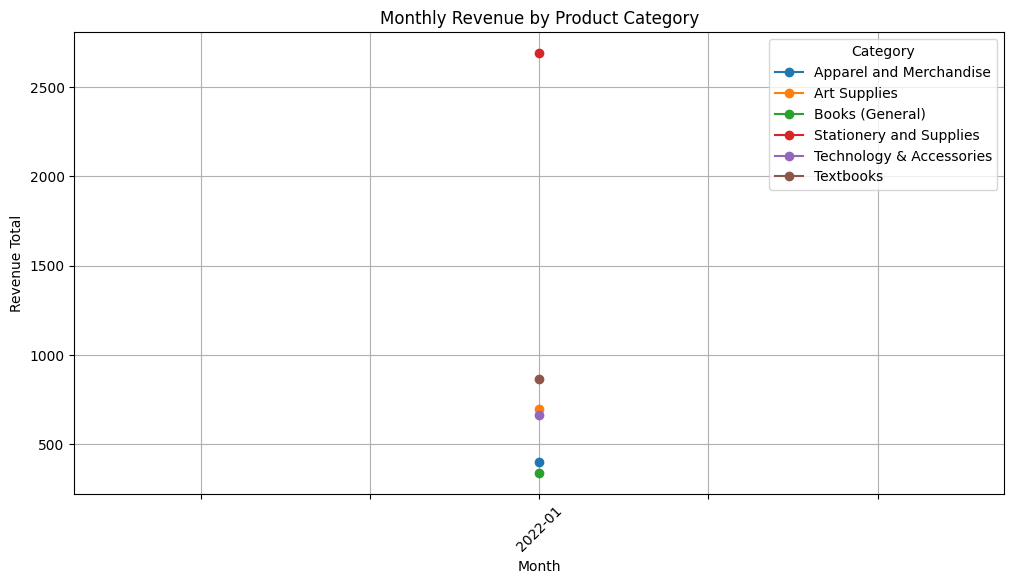

In [170]:
df = pd.read_csv('StoreSales.csv')
dff = pd.read_csv('ProductCategories.csv')

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
monthly_category_transactions = df.groupby([
    df['Transaction Date'].dt.to_period('M'),
    dff['Category'],
])['Sale Amount'].sum()

monthly_category_transactions = (
    monthly_category_transactions.reset_index()
)


monthly_category_transactions.rename(
    columns={'Sale Amount': 'Revenue Total'},
    inplace=True
)


monthly_category_transactions['Transaction Date'] = (
    monthly_category_transactions['Transaction Date'].astype(str)
)


print(monthly_category_transactions)

df = pd.read_csv('StoreSales.csv')
print(df.head())
print(df.columns)

dff = pd.read_csv('ProductCategories.csv')
print(dff.head())
print(dff.columns)

pivot_table = monthly_category_transactions.pivot(
    index='Transaction Date',
    columns='Category',
    values='Revenue Total'
)

pivot_table.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Monthly Revenue by Product Category')
plt.xlabel('Month')
plt.ylabel('Revenue Total')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

There is room for growth in the general books category - perhaps due to disinterest in the genres provided?? I would reccommend doing a survey to see why the general books category is peforming so poorly compared to the other categories.

I recommend focusing our efforts in textbook sales and stationary. As they are our most popular categories, this focus for the next quarter would be for the best.
With the highest stores being 737 and 711 respectively, I believe we should make sure that those stores are supplied with textbooks and stationary tools to maximize customer profits.